# Phase 4 — Model Explainability & Regularized Regression

This notebook extends the predictive population modeling pipeline by adding:

- **Ridge regression**
- **Lasso regression**
- **Permutation importance**
- **SHAP-based explainability** (with a safe fallback if SHAP is unavailable)

It is designed to run from the `analysis/` folder and reuse outputs created in **Phase 2**:
- `../data/processed_puerto_rico_data.csv`
- `./phase2_model_selection_summary.json`

## Objectives

This phase helps align the implementation with the strategy section of the project website by adding:
- regularized regression
- feature-selection logic
- model explainability
- comparison between coefficient-based and tree-based interpretation

## 1. Load libraries and Phase 2 outputs

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

analysis_dir = Path(".")
data_path = Path("../data/processed_puerto_rico_data.csv")
summary_path = analysis_dir / "phase2_model_selection_summary.json"

if not data_path.exists():
    raise FileNotFoundError(f"Could not find processed dataset at: {data_path}")
if not summary_path.exists():
    raise FileNotFoundError(f"Could not find Phase 2 model summary at: {summary_path}")

df = pd.read_csv(data_path)
with open(summary_path, "r") as f:
    phase2_summary = json.load(f)

print("Processed data shape:", df.shape)
print("Phase 2 best model:", phase2_summary.get("best_model_name"))
df.head()

Processed data shape: (936, 65)
Phase 2 best model: Random Forest (tuned)


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,burglary_rate,target_pop_change,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,lag_pop_change_2,income_growth,per_capita_income_inv,split,vulnerability_index
0,2013,Adjuntas,72001,19334,0,15087,79,7298,140,27.2,...,3.206786,-0.637270,0.411142,5.550416,-0.286973,-0.138171,-13.238321,-7235,train,3.251755
1,2014,Adjuntas,72001,19188,0,15080,88,7514,136,34.0,...,1.667709,-0.755146,0.465501,3.206786,-0.637270,-0.286973,-9.938596,-7042,train,3.443797
2,2015,Adjuntas,72001,18962,0,15022,85,7694,126,36.5,...,1.898534,-1.177819,0.312695,1.667709,-0.755146,-0.637270,-0.603827,-7270,train,3.105204
3,2016,Adjuntas,72001,18760,0,14963,78,7673,143,35.6,...,1.599147,-1.065288,0.158211,1.898534,-1.177819,-0.755146,6.244712,-7124,train,2.806677
4,2017,Adjuntas,72001,18525,0,14895,100,7705,150,40.9,...,1.457490,-1.252665,1.066098,1.599147,-1.065288,-1.177819,1.241554,-7117,train,2.701164


## 2. Define feature set and time-aware split

This notebook reuses the same supervised target:
- `target_pop_change`

Metadata columns such as `municipio`, `year`, and `split` are excluded from the feature matrix.
If a `split` column exists, the notebook respects the saved train/test assignment from Phase 2.
Otherwise, it falls back to the same time-aware split used earlier:
- train: `year <= 2020`
- test: `year >= 2021`

In [2]:
target_col = "target_pop_change"
non_feature_cols = ["municipio", "split", "year", target_col]
feature_cols = [
    "vulnerability_index",
    "median_income_real",
    "max_wind_knots",
    "max_seismic_mag",
    "lag_violent_crime_rate",
    "lag_property_crime_rate",
    "lag_pop_change_1",
    "lag_pop_change_2",
    "income_growth"
]

if "split" in df.columns:
    train_df = df[df["split"] == "train"].copy()
    test_df = df[df["split"] == "test"].copy()
else:
    train_df = df[df["year"] <= 2020].copy()
    test_df = df[df["year"] >= 2021].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of features:", len(feature_cols))
feature_cols

Train shape: (624, 9)
Test shape: (312, 9)
Number of features: 9


['vulnerability_index',
 'median_income_real',
 'max_wind_knots',
 'max_seismic_mag',
 'lag_violent_crime_rate',
 'lag_property_crime_rate',
 'lag_pop_change_1',
 'lag_pop_change_2',
 'income_growth']

## 3. Standardize predictors for Ridge and Lasso

Regularized regression is sensitive to scale.  
Standardizing predictors ensures the penalty is applied comparably across features.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Ridge regression

In [4]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 25))
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

ridge_metrics = {
    "R2": float(r2_score(y_test, ridge_pred)),
    "MAE": float(mean_absolute_error(y_test, ridge_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, ridge_pred))),
    "alpha": float(ridge.alpha_)
}

ridge_metrics

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:2109: RuntimeWarning: divide by zero encountered in matmul
  UT_y = U.T @ y
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:2109: RuntimeWarning: overflow encountered in matmul
  UT_y = U.T @ y
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:2109: RuntimeWarning: invalid value encountered in matmul
  UT_y = U.T @ y
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1636: RuntimeWarning: divide by zero encountered in matmul
  abs_cosine = xp.abs(query @ vectors)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1636: RuntimeWarning: overflow encountered in matmul
  abs_cosine = xp.abs(query @ vectors)
/Library/Frameworks/Python.framewo

{'R2': -0.23065227496291762,
 'MAE': 1.9906314342545357,
 'RMSE': 3.136136344820225,
 'alpha': 316.22776601683796}

## 5. Lasso regression

Lasso provides shrinkage and variable selection at the same time.  
Coefficients that are shrunk to zero are effectively excluded from the model.

In [5]:
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

lasso_metrics = {
    "R2": float(r2_score(y_test, lasso_pred)),
    "MAE": float(mean_absolute_error(y_test, lasso_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, lasso_pred))),
    "alpha": float(lasso.alpha_)
}

lasso_metrics

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:179: RuntimeWarning: divide by zero encountered in matmul
  Xyw = X.T @ yw - X_mean * np.sum(yw, axis=0)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:179: RuntimeWarning: overflow encountered in matmul
  Xyw = X.T @ yw - X_mean * np.sum(yw, axis=0)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:179: RuntimeWarning: invalid value encountered in matmul
  Xyw = X.T @ yw - X_mean * np.sum(yw, axis=0)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:858: RuntimeWarning: divide by zero encountered in dot
  np.dot(X.T, X, out=precompute)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:858: Runtime

{'R2': -0.15948340881731404,
 'MAE': 1.839773904160791,
 'RMSE': 3.0441042781480596,
 'alpha': 0.27511858941600414}

## 6. Coefficient review

In [6]:
ridge_coef = pd.Series(ridge.coef_, index=feature_cols, name="ridge_coef").sort_values(
    key=np.abs, ascending=False
)
lasso_coef = pd.Series(lasso.coef_, index=feature_cols, name="lasso_coef").sort_values(
    key=np.abs, ascending=False
)

coef_df = pd.concat([ridge_coef, lasso_coef], axis=1)
coef_df.head(20)

,ridge_coef,lasso_coef
lag_pop_change_1,0.280828,0.205659
median_income_real,0.147628,0.000000
lag_property_crime_rate,0.112139,0.000000
vulnerability_index,0.109752,0.000000
lag_violent_crime_rate,-0.094237,-0.000000
income_growth,0.028495,0.000000
max_wind_knots,0.026911,-0.000000
lag_pop_change_2,0.006025,0.000000
max_seismic_mag,-0.002037,-0.000000


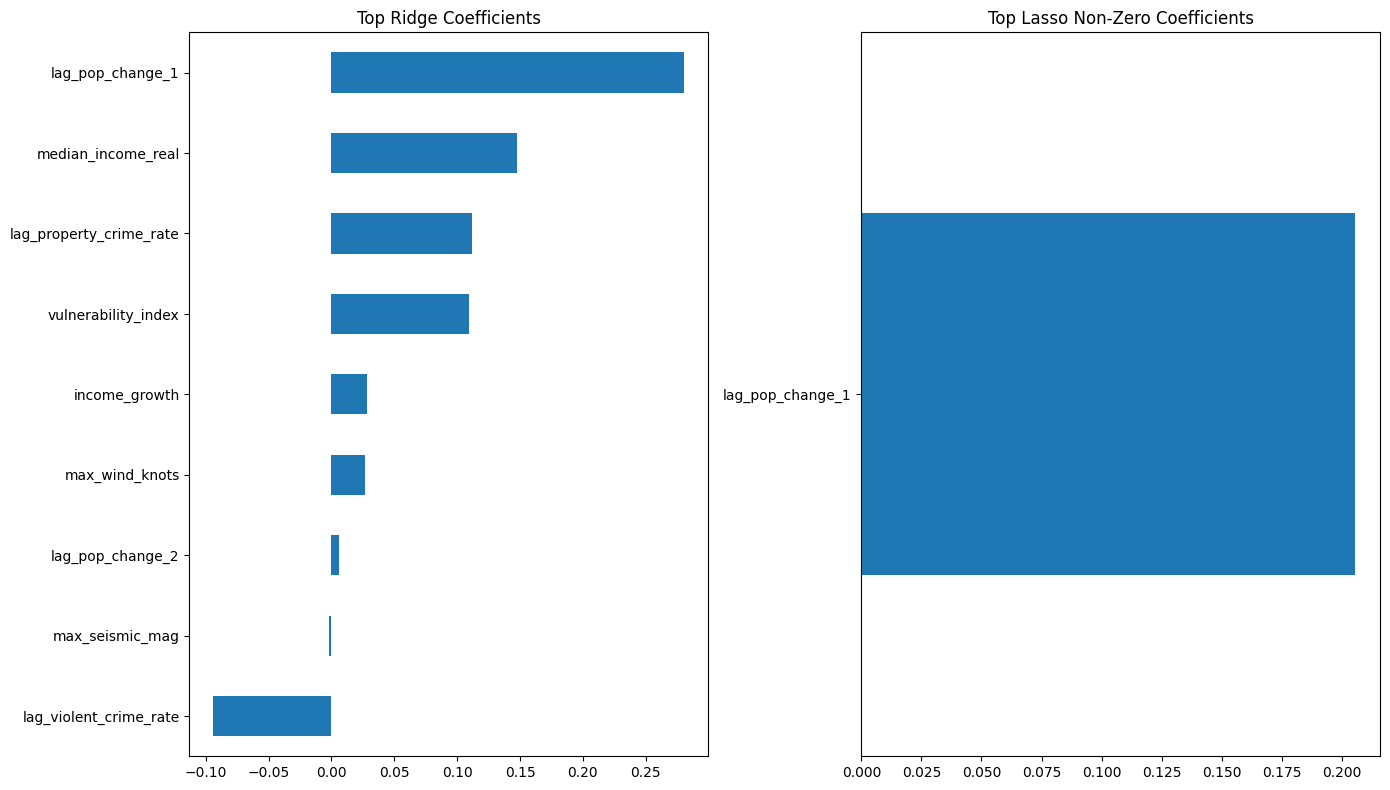

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

ridge_coef.head(15).sort_values().plot(
    kind="barh", ax=axes[0], title="Top Ridge Coefficients"
)

lasso_nonzero = lasso_coef[lasso_coef != 0]
if len(lasso_nonzero) > 0:
    lasso_nonzero.head(15).sort_values().plot(
        kind="barh", ax=axes[1], title="Top Lasso Non-Zero Coefficients"
    )
else:
    axes[1].text(0.5, 0.5, "No non-zero Lasso coefficients", ha="center", va="center")
    axes[1].set_title("Top Lasso Non-Zero Coefficients")

plt.tight_layout()
plt.show()

## 7. Reconstruct the best Phase 2 tree model

This section rebuilds the best-performing Phase 2 nonlinear model using the saved parameter summary.
It supports:
- **Random Forest**
- **HistGradientBoosting**

The reconstructed model is then used for permutation importance and optional SHAP analysis.

In [8]:
best_model_name = phase2_summary.get("best_model_name", "Random Forest (tuned)")
rf_best_params = phase2_summary.get("rf_best_params", {})
hgb_best_params = phase2_summary.get(
    "hgb_best_params",
    phase2_summary.get("lgbm_best_params", {})
)

if "Random Forest" in best_model_name:
    tree_model = RandomForestRegressor(random_state=42, **rf_best_params)
elif "HistGradientBoosting" in best_model_name or "LightGBM" in best_model_name:
    tree_model = HistGradientBoostingRegressor(random_state=42, **hgb_best_params)
else:
    raise ValueError(f"Unsupported best model name: {best_model_name}")

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_metrics = {
    "model_name": best_model_name,
    "R2": float(r2_score(y_test, tree_pred)),
    "MAE": float(mean_absolute_error(y_test, tree_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, tree_pred)))
}

tree_metrics

{'model_name': 'Random Forest (tuned)',
 'R2': -0.25013022737606505,
 'MAE': 1.7662926938974788,
 'RMSE': 3.160857260906036}

## 8. Permutation importance

In [9]:
perm = permutation_importance(
    tree_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head(20)

,feature,importance_mean,importance_std
3,max_seismic_mag,0.000563,0.000593
5,lag_property_crime_rate,0.000279,0.001133
8,income_growth,0.000021,0.001072
2,max_wind_knots,-0.000269,0.000690
4,lag_violent_crime_rate,-0.000390,0.001735
1,median_income_real,-0.001098,0.000588
0,vulnerability_index,-0.001928,0.001588
7,lag_pop_change_2,-0.051524,0.018159
6,lag_pop_change_1,-0.063121,0.015085


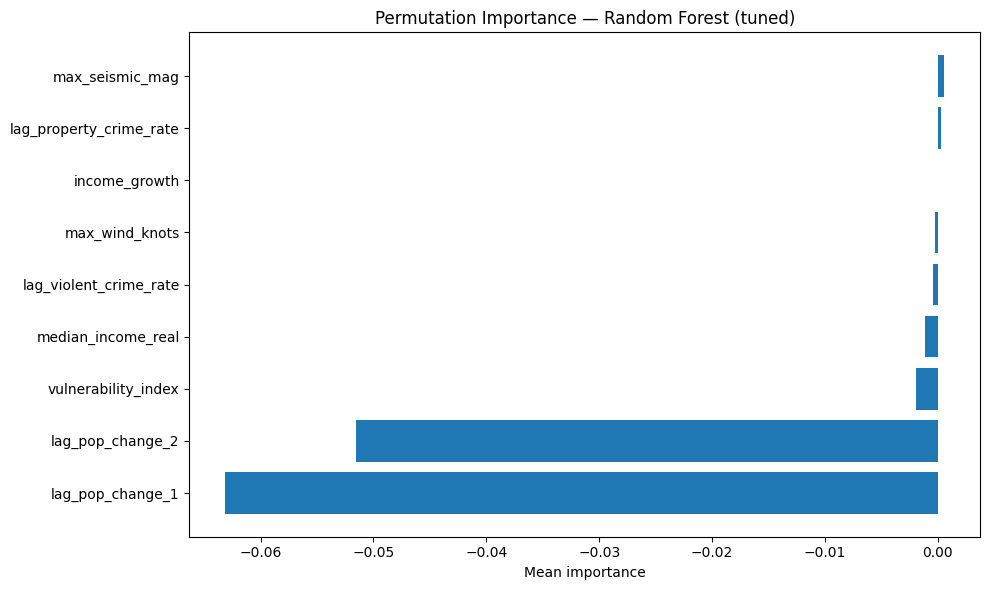

In [10]:
plt.figure(figsize=(10, 6))
plot_df = perm_df.head(15).sort_values("importance_mean")
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title(f"Permutation Importance — {best_model_name}")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()

## 9. SHAP explainability (optional)

If the `shap` package is installed, this section will compute SHAP values.
If SHAP is not installed, the notebook will skip gracefully and continue running.

In [11]:
shap_status = "not_run"

try:
    import shap

    if isinstance(tree_model, RandomForestRegressor):
        shap_explainer = shap.TreeExplainer(tree_model)
        shap_values = shap_explainer.shap_values(X_test)

        shap.summary_plot(shap_values, X_test, show=False)
        plt.title(f"SHAP Summary Plot — {best_model_name}")
        plt.tight_layout()
        plt.show()

        shap_status = "completed"
    else:
        shap_status = "skipped_non_rf_tree_model"
        print("SHAP summary plotting in this notebook is configured only for RandomForestRegressor.")

except Exception as e:
    shap_status = f"skipped: {e}"
    print("SHAP section skipped:", e)

shap_status

SHAP section skipped: No module named 'shap'


"skipped: No module named 'shap'"

## 10. Export explainability summary

In [12]:
explainability_summary = {
    "ridge_metrics": ridge_metrics,
    "lasso_metrics": lasso_metrics,
    "tree_model_metrics": tree_metrics,
    "top_permutation_features": perm_df.head(15).to_dict(orient="records"),
    "shap_status": shap_status
}

out_path = analysis_dir / "phase4_explainability_summary.json"
with open(out_path, "w") as f:
    json.dump(explainability_summary, f, indent=4)

print(f"Explainability summary saved to: {out_path}")

Explainability summary saved to: phase4_explainability_summary.json


## 11. Interpretation

This notebook completes the strategy-page components related to:
- **Ridge / Lasso**
- **feature importance**
- **model explainability**

In your report, you can compare:
- linear regularized models versus nonlinear tree models
- coefficient-based interpretation versus permutation / SHAP-based interpretation